# Tagesmerkmale je HAST und Clusteranalyse

**Zweck:** Jede HAST bekommt für jeden Tag eine Zeile mit wenigen, gut lesbaren Merkmalen.
Die Tage werden nach Außentemperatur in vergleichbare Gruppen geteilt und je Gruppe mit
K-Means geclustert. Die Frage dieses Notebooks:

> **Welche Tagestypen gibt es, und liegen die Tage einer HAST zusammen?**

**Bewusst noch ohne Begehungen.** Ob die Cluster etwas mit Begehungen oder Reparaturen zu
tun haben, ist der nächste Schritt.

**Eingaben**

| Datei | Wofür |
|---|---|
| `data/processed/real_meters/` | Stundenraster je HAST aus [`00_eda`](00_eda_hast_stationsprofile.ipynb) |
| `data/raw/Nodes_Edges.ods` | Anschlusswert je Zähler |
| `data/raw/Zuordnung.xlsx` | Anschlusswert für getauschte Zähler über die Adresse |
| `external/dwd/` | Tagesmitteltemperatur der DWD-Station Kitzingen (öffentlich, gitignored) |

**Eigenständig:** keine Abhängigkeit zu `src/`.

**Vorbefund aus dem Datencheck D2:** Durchfluss, Leistung und Temperaturen sind
**Momentaufnahmen** zur vollen Stunde, keine Stundenmittel. Eine Tagessumme aus
Momentaufnahmen weicht im Winter um bis zu ±30 % ab, im Sommer noch mehr. Deshalb kommen
Tagesenergie und Tagesvolumen aus den **Zählerständen**, die Streuungsmerkmale aus den
Momentaufnahmen.

**Zwei Arten von Werten im Export**
- **Zählerstände** (Energie in kWh, Volumen in m^3) zählen ununterbrochen weiter, wie der Kilometerzähler im Auto. Die Differenz zwischen zwei Ständen ist genau das, was dazwischen durchgeflossen ist.
- **Momentanwerte** (Durchfluss, Leistung, Temperaturen) zeigen, was gerade in diesem Augenblick gemessen wird, wie der Tacho

*Warum ist das ein Problem?*
- Ein Foto kann zufällig eine kurze Warmwasserzapfung treffen oder genau die Pause.
- Beispiel: Jemand duscht 10 Minuten bei 600 l/h, tatsächlich fließen also 100 Liter.
    - Trifft das Foto die Dusche, zählt die Stunde 600 Liter.
    - Verfehlt es sie, zählt die Stunde 0 Liter.
- Summiert man 24 solcher Fotos zu einem Tag, liegt die Summe im Winter um bis zu ±30 % daneben. Im Sommer ist es noch mehr, weil dann fast nur kurze Zapfungen vorkommen.

*Was das Notebook daraus macht* 
- **Tagesenergie und Tagesvolumen** kommen aus den Zählerständen: Stand um Mitternacht minus Stand der Mitternacht davor. Das ist exakt.
- **Die Streuung** kommt aus den Momentaufnahmen. Hier sind sie sogar von Vorteil, denn sie zeigen, wie stark die Werte über den Tag tatsächlich springen. Ein Stundenmittel würde das glätten.

## 1 · Setup & Parameter

In [38]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 40)
plt.rcParams["figure.facecolor"] = "white"

ROOT = Path.cwd().resolve()
while not (ROOT / "notebooks").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

METER_DIR = ROOT / "data" / "processed" / "real_meters"
NODES_PATH = ROOT / "data" / "raw" / "Nodes_Edges.ods"
ZUORDNUNG_PATH = ROOT / "data" / "raw" / "Zuordnung.xlsx"
DWD_DIR = ROOT / "external" / "dwd"
AUSGABE = ROOT / "data" / "processed" / "hast_tage.csv"

# --- Temperaturgruppen (Tagesmittel in °C), Startwerte -----------------------
GRENZEN = [-np.inf, 0, 5, 10, 15, 18, np.inf]
GRUPPEN = ["Heiz <0", "Heiz 0-5", "Heiz 5-10", "Heiz 10-15", "Uebergang 15-18", "Sommer >=18"]

# --- Tageszeilen ---------------------------------------------------------------
RHO_C = 1.15              # kWh je m³ und Kelvin (Wasser bei ~50 °C)
MAX_ABSTAND_H = 2         # Zaehlerstand darf so weit neben Mitternacht liegen
AKTIV_FLUSS_LH = 20       # ab hier zaehlt eine Stunde als "Station laeuft"
MIN_AKTIV_STUNDEN = 6     # weniger laufende Stunden -> keine Streuung fuer diesen Tag
MIN_NACHT_STUNDEN = 4     # gemessene Stunden zwischen 0 und 6 Uhr fuer den Nachtfluss

# --- Markierungen (nichts wird geloescht) ----------------------------------------
MIN_STUNDEN = 12          # gemessene Stunden je Tag (Lauf 1: 20)
MIN_ENERGIE_KWH = 5       # Zaehler zaehlt ganze kWh: Fehler < 1 kWh je Tag, hier < 20 % (Lauf 1: 10)
MAX_KWH_PRO_M3 = 70       # entspricht ~60 K Spreizung, physikalisch unplausibel
STEHT_LEISTUNG_KW = 1.0   # Energiezaehler steht, obwohl im Mittel so viel Leistung anliegt

# --- Clustering ------------------------------------------------------------------
MERKMALE_HEIZ = ["kwh_pro_m3", "volumen_m3_pro_kw", "spreizung_p90_p10_k", "fluss_cv"]
MERKMALE_SOMMER = ["kwh_pro_m3", "volumen_m3_pro_kw", "nachtfluss_lh_pro_kw"]
MERKMALE_JE_GRUPPE = {g: MERKMALE_HEIZ for g in GRUPPEN}
MERKMALE_JE_GRUPPE["Uebergang 15-18"] = MERKMALE_SOMMER  # Lauf 1: Heiz-Merkmale
MERKMALE_JE_GRUPPE["Sommer >=18"] = MERKMALE_SOMMER
K_JE_GRUPPE = {g: 4 for g in GRUPPEN}   # nach Abschnitt 7 anpassen (2 bis 5)
K_JE_GRUPPE["Uebergang 15-18"] = 3      # Lauf 1: 4
K_JE_GRUPPE["Sommer >=18"] = 3          # Lauf 1: 4
K_TEST = range(2, 7)
MIN_TAGE_JE_HAST = 10     # fuer die Frage "liegen die Tage einer HAST zusammen?"
SEED = 42

# --- Farben: geordnete Stufen je K, validiert (eine Farbe, hell = gut -> dunkel = schlecht) ---
# Familie 1 (Heiztage) blau, Familie 2 (Uebergang/Sommer) orange
CLUSTER_FARBEN = {
    2: ["#86b6ef", "#0d366b"],
    3: ["#86b6ef", "#2a78d6", "#0d366b"],
    4: ["#86b6ef", "#3987e5", "#1c5cab", "#0d366b"],
    5: ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#0d366b"],
}
CLUSTER_FARBEN_SOMMER = {
    2: ["#fe9670", "#662000"],
    3: ["#fe9670", "#c74b12", "#662000"],
    4: ["#fe9670", "#e26331", "#b33f01", "#7b2902"],
    5: ["#fe9670", "#ea6b3a", "#c74b12", "#9c3602", "#712400"],
}
FARBE_TATSAECHLICH, FARBE_ZUFALL = "#4a3aa7", "#1baf7a"   # violett / tuerkis, unabhaengig von den Familien
TINTE, TINTE_LEISE, GITTER, ACHSE, FLAECHE = "#0b0b0b", "#52514e", "#e1e0d9", "#c3c2b7", "#fcfcfb"
BUCHSTABEN = "ABCDE"
assert all(2 <= k <= 5 for k in K_JE_GRUPPE.values()), "K muss zwischen 2 und 5 liegen"


def ist_sommerfamilie(gruppe):
    """Gruppen mit den Sommer-Merkmalen (Uebergang, Sommer) bilden Familie 2."""
    return MERKMALE_JE_GRUPPE[gruppe] == MERKMALE_SOMMER


def farben_fuer(gruppe, k):
    """Blaustufen fuer Familie 1 (Heiztage), Orangestufen fuer Familie 2."""
    return (CLUSTER_FARBEN_SOMMER if ist_sommerfamilie(gruppe) else CLUSTER_FARBEN)[k]


def stil(ax):
    """Zurueckhaltende Achsen: nur links/unten, feines Gitter."""
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(ACHSE)
    ax.tick_params(colors=TINTE_LEISE, labelsize=9)
    ax.grid(color=GITTER, linewidth=0.6)
    ax.set_axisbelow(True)

- Alle Schwellen sind **Startwerte** und stehen nur in dieser Zelle.
- **Temperaturgruppen:** Heiztage in 5-K-Bändern, weil sich der Volumenstrom zwischen
  −10 und +10 °C stark ändert. Unter −5 °C gab es 2021–2025 nur 14 Tage, deshalb ein
  gemeinsames Band „unter 0“.
- **Clustermerkmale an Heiz- und Übergangstagen:**
  - `kwh_pro_m3`: Abkühlung, entspricht der mengengewichteten Spreizung × 1,15
  - `volumen_m3_pro_kw`: Tagesvolumen je kW Anschlusswert, unabhängig von der Hausgröße
  - `spreizung_p90_p10_k`: wie stark die Spreizung über den Tag schwankt
  - `fluss_cv`: wie stark der Durchfluss über den Tag schwankt
- **Im Sommer und in der Übergangszeit** ersetzt der Nachtfluss je kW die beiden Streuungen:
  Nachts sollte dann kaum Wasser fließen, und an vielen dieser Tage läuft die Station zu
  selten für eine Streuung. Welche Gruppe welche Merkmale bekommt, steht in
  `MERKMALE_JE_GRUPPE`.
- Die Spreizung selbst wird mitgeführt, aber **nicht** geclustert: Sie ist kWh/m³ ÷ 1,15
  und würde die Abkühlung doppelt zählen.
- **K:** 4 an Heiztagen, 3 in Übergang und Sommer. Erlaubt sind 2 bis 5, für mehr Stufen
  lässt sich die Farbskala nicht mehr sicher unterscheiden.

**Was macht Zelle 1?**
- Pfade: Zählerdaten aus Notebook 00 (`real_meters`), Anschlusswerte aus `Nodes_Edges.ods` und `Zuordnung.xlsx`, Wetter der DWD-Station Kitzingen, Ergebnis nach `hast_tage.csv`
- Alle Schwellen sind **Startwerte** (kann auch andere sinnvolle Schwellen geben) und können nur in dieser Zelle angepasst werden 
- **6 Temperaturgruppen** (Heiz <0, 0–5, 5–10, 10–15 °C, Übergang 15–18 °C, Sommer ≥18 °C) → nur Tage mit ähnlichem Wetter werden miteinander verglichen
- **Markierungen statt Löschen:** unter 12 Messstunden, unter 5 kWh oder über 70 kWh/m³ → Tag wird markiert
--> Markierte Tage bleiben in der Tabelle, fließen aber nicht ins Clustering ein 
--> Leicht änderbar bei Schwellenänderung
- **Clustermerkmale:**
    - Heiztage: kWh/m³, Volumen je kW, Streuung der Spreizung, Schwankung des Durchflusses
    - Übergang und Sommer: kWh/m³, Volumen je kW, Nachtfluss je kW
- Die Spreizung wird **nicht** geclustert: Sie ist kWh/m³ ÷ 1,15 und würde die Abkühlung doppelt zählen
- **K = 4** an Heiztagen, **K = 3** in Übergang und Sommer; `SEED = 42` → jeder Lauf liefert dasselbe Ergebnis
- Farben: geprüfte Blaustufen, hell = gute Abkühlung, dunkel = schlechte


**Lauf 2 (04.10.2026): Änderungen gegenüber Lauf 1**

| Einstellung | Lauf 1 | Lauf 2 | Grund aus Lauf 1 |
|---|---|---|---|
| `MIN_STUNDEN` | 20 | 12 | 17.339 Tage nur wegen zu weniger Stunden markiert; Zählerstände brauchen keine vollständigen Tage |
| `MIN_ENERGIE_KWH` | 10 | 5 | im Sommer 46 % der Tage unter 10 kWh; der Rundungsfehler bleibt unter 20 % |
| Merkmale Übergang | Heiz-Merkmale | Sommer-Merkmale | einem Drittel der nutzbaren Übergangstage fehlte die Streuung |
| K Übergang / Sommer | 4 / 4 | 3 / 3 | Sommer trennt sich klar in Normalbetrieb und Dauerdurchfluss (Silhouette 0,78 bei K = 2), bei K = 4 zerfiel der Dauerdurchfluss in zwei Cluster |
| Clusterbuchstaben | je Gruppe nach kWh/m³ | über die Gruppen abgeglichen | derselbe Typ hieß in „Heiz <0“ C, in den anderen Heizgruppen B |
| Farben Übergang/Sommer (05.10.) | Blaustufen | Orangestufen | sonst mit den Heiztag-Typen verwechselbar, v. a. im Zeitverlauf |

Ergebnis von Lauf 1 in Kürze: An Heiztagen entstanden in allen Bändern dieselben vier Typen
(gute Abkühlung, stark schwankend, gleichmäßig schwach, Dauerdurchfluss). Die Tage einer HAST
lagen deutlich häufiger im selben Cluster als bei Zufall. Klare Gruppen gab es nur im Sommer.

## 2 · Wetter: Tagesmitteltemperatur und Gruppen

In [39]:
def lade_dwd(ordner):
    """Tagesmitteltemperatur (TMK) aus allen produkt_klima_tag-Dateien im Ordner."""
    dateien = sorted(Path(ordner).rglob("produkt_klima_tag_*.txt"))
    if not dateien:
        raise FileNotFoundError(f"keine DWD-Datei unter {ordner}")
    teile = []
    for f in dateien:
        d = pd.read_csv(f, sep=";", skipinitialspace=True)
        d.columns = d.columns.str.strip()
        teile.append(d[["MESS_DATUM", "QN_4", "TMK"]])
    w = pd.concat(teile, ignore_index=True)
    w["datum"] = pd.to_datetime(w["MESS_DATUM"].astype(str), format="%Y%m%d").astype("datetime64[ns]")
    w["TMK"] = w["TMK"].where(w["TMK"] != -999)
    # Ueberlappen historische und aktuelle Datei, gewinnt die besser gepruefte Zeile
    w = w.sort_values("QN_4", ascending=False).drop_duplicates("datum")
    return w.set_index("datum").sort_index()["TMK"].rename("t_mittel_c")


wetter = lade_dwd(DWD_DIR)
wetter_gruppe = pd.cut(wetter, GRENZEN, right=False, labels=GRUPPEN)
print(f"Wetter: {wetter.index.min().date()} bis {wetter.index.max().date()}, "
      f"fehlende Tagesmittel: {int(wetter.isna().sum())}")
ab = wetter.index >= "2022-01-01"
display(pd.crosstab(wetter.index.year[ab].to_numpy(), wetter_gruppe[ab].to_numpy(),
                    rownames=["jahr"], colnames=["gruppe"]).reindex(columns=GRUPPEN, fill_value=0))

Wetter: 1982-11-01 bis 2025-12-31, fehlende Tagesmittel: 0


gruppe,Heiz <0,Heiz 0-5,Heiz 5-10,Heiz 10-15,Uebergang 15-18,Sommer >=18
jahr,,,,,,
2022,12,76,77,68,32,100
2023,17,57,82,67,50,92
2024,21,43,91,74,46,91
2025,30,65,69,80,47,74


- Station **Kitzingen** (DWD 2600), rund 13 km von Wiesentheid. 2021–2025 lückenlos,
  vollständig geprüft (Qualitätsstufe 10).
- Jeder Tag bekommt genau eine Gruppe. Verglichen und geclustert wird nur innerhalb einer
  Gruppe, damit kein Sommertag neben einem Wintertag landet.
- Die Datei endet am 31.12.2025. Für 2026 gibt es ohnehin keine Zählerstände (Check D2),
  diese Tage werden als `ohne_wetter` markiert.

**Was macht die Zelle**
- lade_dwd() sucht alle DWD-Dateien produkt_klima_tag_*.txt in external/dwd/. Kommt später die aktuelle Datei dazu, wird sie automatisch mitgelesen
- Aus jeder Datei nimmt sie drei Spalten: Datum, Qualitätsstufe (QN_4) und Tagesmitteltemperatur (TMK)
- pd.cut ordnet jedem Tag über die Grenzen aus Abschnitt 1 genau eine der 6 Gruppen zu
- Ausgegeben werden der Zeitraum, die Zahl fehlender Werte und eine Tabelle mit den Tagen je Jahr und Gruppe ab 2022

**Was das Ergebnis aussagt** 
- Die Daten reichen bis zum 31.12.2025, ohne einen fehlenden Tag.
- Pro Jahr gibt es etwa 230–250 Heiztage, 32–50 Übergangstage und 74–100 Sommertage.
- Die Jahre unterscheiden sich: 2022 hatte den wärmsten Sommer (100 Sommertage), 2025 die meisten Frosttage (30).
- Die Gruppe „Heiz <0“ ist mit 12–30 Tagen pro Jahr am kleinsten. Deshalb ist alles unter 0 °C in einer Gruppe zusammengefasst.
- 2026 fehlt in der Datei. Diese Tage werden später als ohne_wetter markiert.

## 3 · Anschlusswert je Zähler

In [40]:
def adresse_norm(s):
    """Wie _normalize_address in src/load_data.py plus Tippfehler aus src/load_begehungen.py.

    Bewusst hier dupliziert, damit das Notebook eigenstaendig bleibt.
    """
    if not isinstance(s, str):
        return ""
    t = s.lower().strip().replace("ß", "ss")
    t = t.replace("ä", "ae").replace("ö", "oe").replace("ü", "ue")
    t = re.sub(r"\.", "", t)
    t = re.sub(r"str(asse)?\b", "strasse", t)
    t = re.sub(r"\s+", " ", t)
    t = re.sub(r"[^a-z0-9 \-]", "", t)
    t = re.sub(r"(\d)\s+([a-z])\b", r"\1\2", t)
    t = re.sub(r"\s*-\s*", "-", t)
    return t.strip().replace("fleiderstrasse", "fliederstrasse")


zaehler_dateien = sorted(METER_DIR.glob("*.csv"))
if not zaehler_dateien:
    raise FileNotFoundError(f"keine Zaehlerdateien in {METER_DIR} - zuerst Notebook 00 ausfuehren")

# Nodes_Edges: Anschlusswert je Zaehlernummer
nodes = pd.read_excel(NODES_PATH, sheet_name="Nodes")
nodes["zaehler"] = pd.to_numeric(nodes["Zählernummer"], errors="coerce")
nodes["aw"] = pd.to_numeric(nodes["Anschlusswert"], errors="coerce")
nodes = nodes.dropna(subset=["zaehler"])
nodes["zaehler"] = nodes["zaehler"].astype(int)
aw_direkt = nodes[nodes["aw"] > 0].groupby("zaehler")["aw"].max()
aw_je_adresse = {}
for adresse, aw in zip(nodes["Straße"], nodes["aw"]):
    if aw > 0:
        aw_je_adresse.setdefault(adresse_norm(adresse), set()).add(float(aw))

# Zuordnung.xlsx: ein Blatt je Jahr; 2024/2025 mit "Abnahmestelle", 2026 mit Strasse und Hausnummer getrennt
blaetter = []
for blatt in pd.ExcelFile(ZUORDNUNG_PATH).sheet_names:
    z = pd.read_excel(ZUORDNUNG_PATH, sheet_name=blatt)
    sp = list(z.columns)
    if len(sp) > 3 and "Hausnr" in str(sp[2]):
        adresse = z[sp[1]].astype(str).str.strip() + " " + z[sp[2]].astype(str).str.strip()
    else:
        adresse = z[sp[2]]
    blaetter.append(pd.DataFrame({"zaehler": pd.to_numeric(z[sp[0]], errors="coerce"),
                                  "adresse": adresse}))
zuordnung = pd.concat(blaetter, ignore_index=True).dropna()
zuordnung["zaehler"] = zuordnung["zaehler"].astype(int)
zuordnung["key"] = zuordnung["adresse"].map(adresse_norm)
zuordnung = zuordnung[zuordnung["key"].str.len() > 3]

anschluss, quelle = {}, {}
for z in (int(p.stem) for p in zaehler_dateien):
    if z in aw_direkt.index:
        anschluss[z], quelle[z] = float(aw_direkt[z]), "Nodes_Edges"
        continue
    kandidaten = set()
    for key in set(zuordnung.loc[zuordnung["zaehler"] == z, "key"]):
        kandidaten |= aw_je_adresse.get(key, set())
    if len(kandidaten) == 1:
        anschluss[z], quelle[z] = kandidaten.pop(), "Zuordnung (Adresse)"
    else:
        quelle[z] = "mehrdeutig" if kandidaten else "fehlt"

print("Herkunft des Anschlusswerts (Anzahl Zaehler):")
print(pd.Series(quelle).value_counts().to_string())

Herkunft des Anschlusswerts (Anzahl Zaehler):
Nodes_Edges            85
fehlt                   7
Zuordnung (Adresse)     3
mehrdeutig              1


- Erst direkt über die Zählernummer in `Nodes_Edges.ods`. Fehlt sie dort, weil der Zähler
  getauscht wurde, über die Adresse in `Zuordnung.xlsx`.
- Laut Check D2 erwartet: 85 direkt, 3 über die Adresse, 1 mehrdeutig, 7 ohne Wert.
- Zähler ohne Anschlusswert bleiben in der Tabelle, fallen aber aus dem Clustering, weil
  `volumen_m3_pro_kw` fehlt.
- Die Adress-Normierung ist eine Kopie aus `src/`, damit das Notebook eigenständig bleibt.

**Was ist der Anschlusswert?**
- Vertraglich vereinbarte **Höchstleistung in kW**, die ein Gebäude gleichzeitig aus dem Netz beziehen darf 
- Ausgelegt auf den kältesten Tag (Heizlast + Warmwasser), danach werden HAST, Wärmetauscher und Regelventil bemessen
- Der Kunde zahlt dafür üblicherweise einen Grundpreis je kW, egal wie viel er tatsächlich verbraucht
- In unseren Daten typisch **5–17 kW** (Wohnhäuser), zwei große Verbraucher mit **500 kW**
- Quelle ist immer `Nodes_Edges.ods`; `Zuordnung.xlsx` dient nur als Brücke über die Adresse (getauschte Zähler)

**Beispiel: Anschlusswert 8 kW**
- Höchstens 8 kW gleichzeitig → maximal 8 × 24 = 192 kWh am Tag; meist wird nur ein Teil genutzt (bei 0–5 °C etwa 2–3 kW)
- Wasserbedarf bei voller Leistung: ~230 l/h bei 30 K Spreizung, aber ~460 l/h bei nur 15 K → schlechte Abkühlung kostet doppelt so viel Wasser
- Der Wert allein sagt nichts über gut oder schlecht, er ist nur eine **Größenangabe**
- Erst **Volumen je kW** zeigt das Verhalten: Typ A (gute Abkühlung) braucht bei 0–5 °C ~1,8 m³/Tag, Typ D (Dauerdurchfluss) 8–10 m³/Tag

## 4 · Tageszeilen bauen

- **Tagesenergie und Tagesvolumen:** Differenz der Zählerstände von Mitternacht zu
  Mitternacht. Fehlt der Stand genau um 0 Uhr, nimmt die Zelle den nächsten im Abstand von
  höchstens 2 h und rechnet auf 24 h um. Lücken mitten am Tag stören nicht, weil der
  Zähler weiterzählt.
- **kWh/m³** = Tagesenergie ÷ Tagesvolumen. Das ist die mengengewichtete Spreizung × 1,15
  und unabhängig von der Hausgröße.
- **Streuung** aus den Momentaufnahmen, nur über Stunden mit mindestens 20 l/h:
  Spreizung p90 − p10 und Variationskoeffizient des Durchflusses (Standardabweichung ÷
  Mittelwert).
- **Nachtfluss:** kleinster gemessener Durchfluss zwischen 0 und 6 Uhr.
- **Vor- und Rücklauf** mengengewichtet, nur zum Mitlesen.

In [41]:
SPALTEN = {
    "Energy (kWh)": "energie", "Volume flow (l/h)": "fluss", "Power (kW)": "leistung",
    "Temperature difference (°C)": "spreizung", "Flow temperature (°C)": "vorlauf",
    "Return temperature (°C)": "ruecklauf", "Volume (m³)": "volumen",
}


def zaehler_differenz(gem, tage_idx):
    """Energie und Volumen je Tag aus den Zaehlerstaenden um Mitternacht."""
    staende = gem[["energie", "volumen"]].dropna().rename_axis("ts").reset_index()
    if staende.empty:
        return pd.DataFrame(index=tage_idx, columns=["energie_kwh", "volumen_m3", "zaehler_spanne_h"],
                            dtype=float)
    grenzen = pd.DataFrame({"grenze": pd.date_range(tage_idx.min(), tage_idx.max() + pd.Timedelta(days=1),
                                                    freq="D").astype("datetime64[ns]")})
    nah = pd.merge_asof(grenzen, staende, left_on="grenze", right_on="ts", direction="nearest",
                        tolerance=pd.Timedelta(hours=MAX_ABSTAND_H))
    a, b = nah.iloc[:-1].reset_index(drop=True), nah.iloc[1:].reset_index(drop=True)
    spanne = (b["ts"] - a["ts"]).dt.total_seconds() / 3600
    out = pd.DataFrame({
        "energie_kwh": (b["energie"] - a["energie"]) * 24 / spanne,
        "volumen_m3": (b["volumen"] - a["volumen"]) * 24 / spanne,
        "zaehler_spanne_h": spanne,
    })
    out.index = pd.DatetimeIndex(a["grenze"])
    return out.reindex(tage_idx)


def tageswerte(pfad):
    """Eine Zeile je Tag fuer einen Zaehler."""
    df = pd.read_csv(pfad, parse_dates=["Timestamp"]).rename(columns=SPALTEN)
    df = df.set_index("Timestamp").sort_index()
    df.index = df.index.astype("datetime64[ns]")
    gem = df.dropna(subset=["fluss"])                     # nur gemessene Stunden
    if gem.empty:
        return None
    tag = gem.index.normalize()
    tage_idx = tag.unique()

    g = gem.groupby(tag)
    out = pd.DataFrame({"n_stunden": g.size(),
                        "fluss_mittel_lh": g["fluss"].mean(),
                        "leistung_mittel_kw": g["leistung"].mean()})

    # Vor- und Ruecklauf mengengewichtet (Gewicht = Durchfluss der Momentaufnahme)
    q = gem["fluss"].clip(lower=0)
    s = pd.DataFrame({"q": q, "qv": q * gem["vorlauf"], "qr": q * gem["ruecklauf"]}).groupby(tag).sum()
    out["vorlauf_c"] = s["qv"] / s["q"].where(s["q"] > 0)
    out["ruecklauf_c"] = s["qr"] / s["q"].where(s["q"] > 0)

    # Streuung ueber die Stunden, in denen die Station laeuft
    akt = gem[gem["fluss"] >= AKTIV_FLUSS_LH]
    ga = akt.groupby(akt.index.normalize())
    out["n_aktiv"] = ga.size().reindex(tage_idx, fill_value=0)
    genug = out["n_aktiv"] >= MIN_AKTIV_STUNDEN
    p90_p10 = ga["spreizung"].quantile(0.9) - ga["spreizung"].quantile(0.1)
    out["spreizung_p90_p10_k"] = p90_p10.reindex(tage_idx).where(genug)
    out["fluss_cv"] = (ga["fluss"].std() / ga["fluss"].mean()).reindex(tage_idx).where(genug)

    # Nachtfluss: kleinster Durchfluss zwischen 0 und 6 Uhr
    nacht = gem[gem.index.hour < 6]
    gn = nacht.groupby(nacht.index.normalize())["fluss"]
    out["nachtfluss_lh"] = gn.min().clip(lower=0).where(gn.size() >= MIN_NACHT_STUNDEN).reindex(tage_idx)

    out = out.join(zaehler_differenz(gem, tage_idx))
    out["kwh_pro_m3"] = out["energie_kwh"] / out["volumen_m3"].where(out["volumen_m3"] > 0)
    out["spreizung_k"] = out["kwh_pro_m3"] / RHO_C
    out.index.name = "datum"
    return out.reset_index().assign(zaehler=int(pfad.stem))


teile = [tageswerte(p) for p in zaehler_dateien]
tage = pd.concat([t for t in teile if t is not None], ignore_index=True)
tage["anschlusswert_kw"] = tage["zaehler"].map(anschluss)
tage["volumen_m3_pro_kw"] = tage["volumen_m3"] / tage["anschlusswert_kw"]
tage["nachtfluss_lh_pro_kw"] = tage["nachtfluss_lh"] / tage["anschlusswert_kw"]
tage["t_mittel_c"] = tage["datum"].map(wetter)
tage["gruppe"] = pd.cut(tage["t_mittel_c"], GRENZEN, right=False, labels=GRUPPEN)
print(f"{len(tage):,} Tageszeilen aus {tage['zaehler'].nunique()} Zaehlern, "
      f"{tage['datum'].min().date()} bis {tage['datum'].max().date()}")

89,142 Tageszeilen aus 96 Zaehlern, 2021-11-01 bis 2026-07-20


- Eine Zeile ist **eine HAST an einem Tag**. Gezählt werden nur Tage mit mindestens einer
  gemessenen Stunde.
- Der Umweg über die Zählerstände ist nötig, weil die Stundenwerte Momentaufnahmen sind
  (Check D2). Die Zählerstände sind dagegen das echte Integral.
- **Achtung, Zählertausch:** Zähler werden hier nicht zusammengeführt. Eine HAST mit
  Zählertausch erscheint als zwei Zähler.

**Zusammenfassung**
- Macht aus dem Stundenraster jeder HAST **eine Zeile pro Tag** (nur gemessene Stunden)
- **Aus den Zählerständen** (Mitternacht zu Mitternacht, notfalls Stand bis 2 h daneben, auf 24 h umgerechnet): Tagesenergie, Tagesvolumen, **kWh/m³** und Spreizung (kWh/m³ ÷ 1,15) → exakt
- **Aus den Momentaufnahmen:**
    - Streuung der Spreizung (p90 − p10) und Schwankung des Durchflusses (Variationskoeffizient), nur Stunden ab 20 l/h, mindestens 6 davon
    - Nachtfluss = kleinster Durchfluss zwischen 0 und 6 Uhr
    - Vor- und Rücklauf mengengewichtet (zum Mitlesen)
- Danach kommen Anschlusswert, Temperatur und Gruppe dazu → Volumen und Nachtfluss **je kW**
- Ergebnis: **89.142 Tageszeilen von 96 Zählern** (11/2021–07/2026), noch inklusive unbrauchbarer Tage
- Einschränkung: Zählertausch nicht zusammengeführt → eine HAST mit Tausch erscheint als zwei Zähler


## 5 · Tage markieren statt löschen

In [42]:
gruende = {
    "kein_zaehlerstand": tage["energie_kwh"].isna() | tage["volumen_m3"].isna(),
    "ruecksprung": (tage["energie_kwh"] < 0) | (tage["volumen_m3"] < 0),
    "zaehler_steht": ((tage["volumen_m3"] == 0) & (tage["fluss_mittel_lh"] >= AKTIV_FLUSS_LH))
                     | ((tage["energie_kwh"] == 0) & (tage["leistung_mittel_kw"] >= STEHT_LEISTUNG_KW)),
    "wenig_energie": tage["energie_kwh"] < MIN_ENERGIE_KWH,
    "unplausibel": tage["kwh_pro_m3"] > MAX_KWH_PRO_M3,
    "wenig_stunden": tage["n_stunden"] < MIN_STUNDEN,
    "ohne_wetter": tage["gruppe"].isna(),
}
# Am Tag nach einem stehenden Zaehler holt der Zaehler meist auf: auch markieren
steht = tage.loc[gruende["zaehler_steht"], ["zaehler", "datum"]]
folgetag = pd.MultiIndex.from_arrays([steht["zaehler"], steht["datum"] + pd.Timedelta(days=1)])
gruende["nach_stillstand"] = pd.Series(
    pd.MultiIndex.from_arrays([tage["zaehler"], tage["datum"]]).isin(folgetag), index=tage.index)

grund = pd.Series("", index=tage.index)
for name, maske in gruende.items():
    grund = grund.where(~maske, grund + name + ", ")
tage["grund"] = grund.str.rstrip(", ")
tage["nutzbar"] = tage["grund"] == ""

uebersicht = pd.DataFrame({"Tage": tage.groupby("gruppe", observed=False).size(),
                           "nutzbar": tage[tage["nutzbar"]].groupby("gruppe", observed=False).size()})
for name, maske in gruende.items():
    if name != "ohne_wetter":
        uebersicht[name] = maske.groupby(tage["gruppe"], observed=False).sum()
display(uebersicht)
print(f"ohne Wetter (z. B. 2026): {int(gruende['ohne_wetter'].sum()):,} Tage")
print(f"nutzbar insgesamt: {int(tage['nutzbar'].sum()):,} von {len(tage):,} Tagen")

,Tage,nutzbar,kein_zaehlerstand,ruecksprung,zaehler_steht,wenig_energie,unplausibel,wenig_stunden,nach_stillstand
gruppe,,,,,,,,,
Heiz <0,5295,4631,191,1,0,195,0,290,0
Heiz 0-5,15450,10564,478,2,0,612,0,3987,0
Heiz 5-10,20671,15673,580,0,3,869,0,3852,2
Heiz 10-15,17451,12834,627,0,1,1234,0,3043,2
Uebergang 15-18,9686,6712,438,0,1,1432,3,1436,1
Sommer >=18,19584,10994,932,0,19,4460,16,4528,19


ohne Wetter (z. B. 2026): 1,005 Tage
nutzbar insgesamt: 61,408 von 89,142 Tagen


| Markierung | Bedeutung |
|---|---|
| `kein_zaehlerstand` | kein Zählerstand nahe Mitternacht, z. B. ODS-Zeiträume oder Lücken |
| `ruecksprung` | Zählerstand sinkt: Zählertausch oder Reset |
| `zaehler_steht` | Zählerstand bewegt sich nicht, obwohl laut Momentaufnahmen Wasser fließt bzw. Leistung anliegt |
| `nach_stillstand` | Tag nach einem stehenden Zähler: Dort holt der Zähler meist auf |
| `wenig_energie` | unter 5 kWh am Tag: Rundung auf ganze kWh macht kWh/m³ ungenau |
| `unplausibel` | über 70 kWh/m³ |
| `wenig_stunden` | weniger als 12 gemessene Stunden |
| `ohne_wetter` | kein Tagesmittel vorhanden |

- Ein Tag kann mehrere Markierungen haben. **Nutzbar** heißt: keine Markierung.
- Gelöscht wird nichts, die Markierungen stehen mit in der gespeicherten Tabelle.

**Zusammenfassung**
- Prüft jeden Tag auf 8 Probleme (kein Zählerstand, Rücksprung, Zähler steht, Tag nach Stillstand, unter 5 kWh, über 70 kWh/m³, unter 12 Messstunden, kein Wetter) → **markieren statt löschen**
- `grund` = alle zutreffenden Gründe, `nutzbar` = kein Grund; ein Tag kann mehrere Gründe haben
- Ergebnis: **61.408 von 89.142 Tagen nutzbar (69 %)**; Heiz <0 87 %, übrige Heizgruppen 68–76 %, Übergang 69 %, Sommer nur 56 %
- Größter Verlust: **unter 12 Messstunden** (17.136 Tage), Ursache noch offen
- Zweitgrößter: **unter 5 kWh** (8.802 Tage, davon 4.460 im Sommer) → kleine Häuser brauchen im Sommer nur wenig Warmwasser
- Zählerstände fast immer in Ordnung: Rücksprung 3, Zähler steht 24, unplausibel 19
- Folge: Im Sommer bleiben eher größere und verbrauchsstarke Stationen übrig → Sommer-Ergebnisse etwas in diese Richtung verzerrt


## 6 · Merkmale ansehen

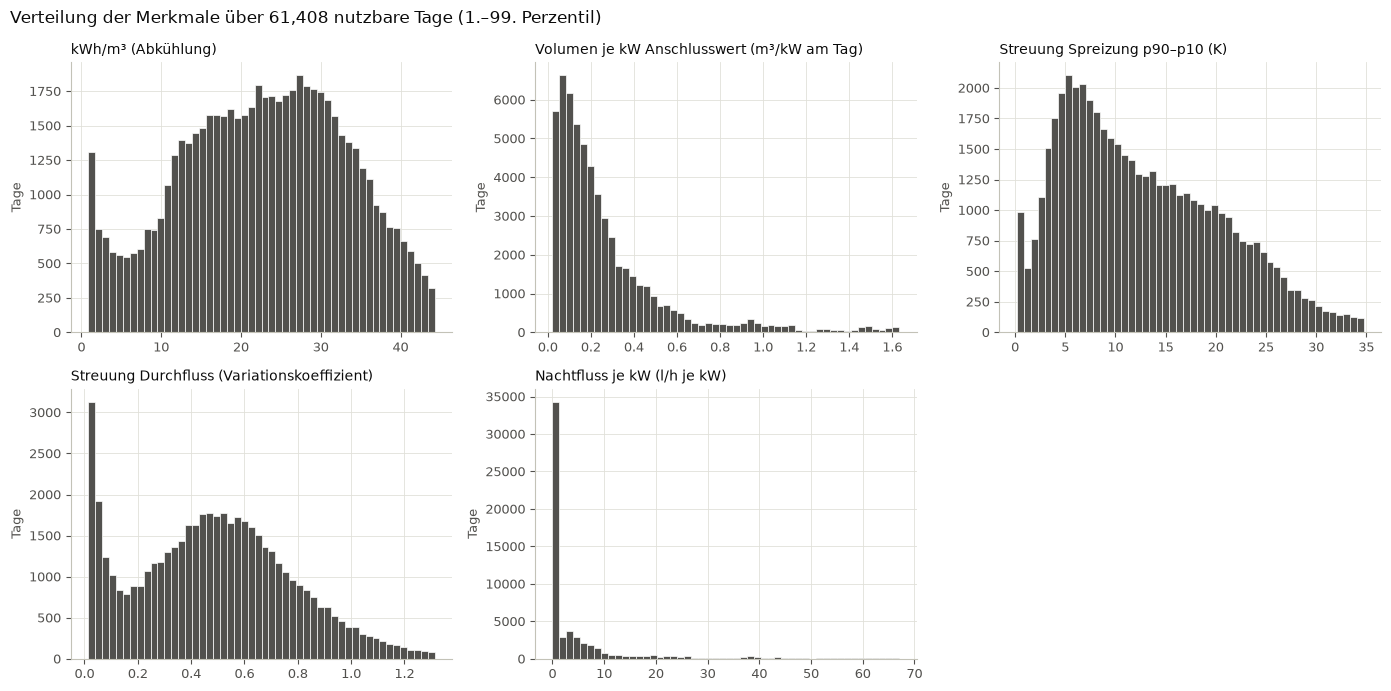

Rangkorrelation (Spearman) der Merkmale:


,kwh_pro_m3,volumen_m3_pro_kw,spreizung_p90_p10_k,fluss_cv,nachtfluss_lh_pro_kw
kwh_pro_m3,1.00,-0.20,0.29,0.35,-0.12
volumen_m3_pro_kw,-0.20,1.00,-0.07,-0.47,0.61
spreizung_p90_p10_k,0.29,-0.07,1.00,0.40,-0.21
fluss_cv,0.35,-0.47,0.40,1.00,-0.47
nachtfluss_lh_pro_kw,-0.12,0.61,-0.21,-0.47,1.00


In [43]:
BESCHRIFTUNG = {
    "kwh_pro_m3": "kWh/m³ (Abkühlung)",
    "volumen_m3_pro_kw": "Volumen je kW Anschlusswert (m³/kW am Tag)",
    "spreizung_p90_p10_k": "Streuung Spreizung p90–p10 (K)",
    "fluss_cv": "Streuung Durchfluss (Variationskoeffizient)",
    "nachtfluss_lh_pro_kw": "Nachtfluss je kW (l/h je kW)",
}
nutz = tage[tage["nutzbar"]]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, sp in zip(axes.flat, BESCHRIFTUNG):
    w = nutz[sp].dropna()
    unten, oben = w.quantile([0.01, 0.99])
    ax.hist(w, bins=50, range=(unten, oben), color=TINTE_LEISE, edgecolor="white", linewidth=0.5)
    ax.set_title(BESCHRIFTUNG[sp], loc="left", fontsize=10, color=TINTE)
    ax.set_ylabel("Tage", fontsize=9, color=TINTE_LEISE)
    stil(ax)
axes.flat[-1].axis("off")
fig.suptitle(f"Verteilung der Merkmale über {len(nutz):,} nutzbare Tage (1.–99. Perzentil)",
             x=0.01, ha="left", color=TINTE)
fig.tight_layout()
plt.show()

print("Rangkorrelation (Spearman) der Merkmale:")
display(nutz[list(BESCHRIFTUNG)].corr(method="spearman").round(2))

- Schiefe Verteilungen sind normal. Für das Clustering werden Ausreißer je Gruppe auf das
  1.–99. Perzentil begrenzt und danach standardisiert.
- Hängen zwei Merkmale sehr eng zusammen (|Korrelation| über 0,8), messen sie fast dasselbe
  und gewichten diese Information im Clustering doppelt.

## 7 · Wie viele Cluster? Silhouette je Gruppe

In [44]:
def matrix(gruppe):
    """Nutzbare Tage einer Gruppe und ihre standardisierte Merkmalsmatrix."""
    sp = MERKMALE_JE_GRUPPE[gruppe]
    teil = tage[(tage["gruppe"] == gruppe) & tage["nutzbar"]].dropna(subset=sp)
    if len(teil) < 50:
        return teil, None
    X = teil[sp].clip(teil[sp].quantile(0.01), teil[sp].quantile(0.99), axis=1)
    return teil, StandardScaler().fit_transform(X)


zeilen = []
for gruppe in GRUPPEN:
    teil, Z = matrix(gruppe)
    zeile = {"gruppe": gruppe, "nutzbar": int(((tage["gruppe"] == gruppe) & tage["nutzbar"]).sum()),
             "mit allen Merkmalen": len(teil), "HAST": teil["zaehler"].nunique()}
    for k in K_TEST:
        if Z is not None and len(teil) > 10 * k:
            lab = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit_predict(Z)
            zeile[f"k={k}"] = silhouette_score(Z, lab, sample_size=min(5000, len(Z)), random_state=SEED)
    zeilen.append(zeile)
silhouette = pd.DataFrame(zeilen).set_index("gruppe")
display(silhouette.round(3))

,nutzbar,mit allen Merkmalen,HAST,k=2,k=3,k=4,k=5,k=6
gruppe,,,,,,,,
Heiz <0,4631,4355,88,0.333,0.287,0.266,0.261,0.262
Heiz 0-5,10564,9870,88,0.366,0.299,0.290,0.277,0.279
Heiz 5-10,15673,14156,88,0.413,0.290,0.299,0.289,0.269
Heiz 10-15,12834,10133,88,0.402,0.291,0.284,0.301,0.297
Uebergang 15-18,6712,6407,88,0.738,0.485,0.528,0.470,0.484
Sommer >=18,10994,10550,87,0.754,0.492,0.530,0.475,0.483


- Die **Silhouette** misst, wie klar die Tage zu ihrem Cluster gehören: 1 = klar getrennt,
  0 = auf der Grenze. Unter 0,25 gilt die Struktur als schwach (Kontinuum statt Gruppen).
- `mit allen Merkmalen` und `HAST` zeigen, wie viel tatsächlich geclustert wird.
- Liegt `mit allen Merkmalen` deutlich unter `nutzbar`, fehlen meist die Streuungen: An Tagen
  mit wenig Betrieb läuft die Station weniger als 6 Stunden mit Durchfluss. Dann für diese
  Gruppe die Sommer-Merkmale nehmen (`MERKMALE_JE_GRUPPE` in Abschnitt 1).
- K wird **fest gesetzt** (`K_JE_GRUPPE` in Abschnitt 1), nicht automatisch nach der
  höchsten Silhouette. Kleine Unterschiede sind Rauschen.

## 8 · Clustern und Cluster beschreiben

In [45]:
tage["cluster_rang"] = np.nan
roh = {}
for gruppe in GRUPPEN:
    k = K_JE_GRUPPE[gruppe]
    teil, Z = matrix(gruppe)
    if Z is None or len(teil) <= 10 * k:
        print(f"{gruppe}: zu wenige Tage ({len(teil)}), uebersprungen")
        continue
    roh[gruppe] = {"teil": teil, "Z": Z, "k": k,
                   "km": KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(Z)}

# Familien: Gruppen mit gleichen Merkmalen und gleichem K bekommen dieselben Buchstaben
familien = {}
for gruppe, e in roh.items():
    familien.setdefault((tuple(MERKMALE_JE_GRUPPE[gruppe]), e["k"]), []).append(gruppe)

ergebnisse, abgleich = {}, []
for (_, k), mitglieder in familien.items():
    # Referenz = Gruppe mit den meisten Tagen, ihre Cluster nach Abkuehlung geordnet (Rang 0 = A)
    ref = max(mitglieder, key=lambda g: len(roh[g]["teil"]))
    r = roh[ref]
    reihenfolge = (r["teil"].groupby(r["km"].labels_)["kwh_pro_m3"].median()
                   .sort_values(ascending=False).index.to_numpy())
    ref_zentren = r["km"].cluster_centers_[reihenfolge]
    for gruppe in mitglieder:
        e = roh[gruppe]
        # jedes Cluster bekommt den Buchstaben des naechsten Referenzzentrums (eindeutige Zuordnung)
        kosten = np.sqrt(((e["km"].cluster_centers_[:, None, :] - ref_zentren[None, :, :]) ** 2).sum(axis=2))
        label, rang = linear_sum_assignment(kosten)
        rang_je_label = dict(zip(label, rang))
        rang_je_tag = np.array([rang_je_label[lab] for lab in e["km"].labels_])
        tage.loc[e["teil"].index, "cluster_rang"] = rang_je_tag
        ergebnisse[gruppe] = {"teil": e["teil"], "Z": e["Z"], "rang": rang_je_tag, "k": k, "referenz": ref}
        abgleich.append({"gruppe": gruppe, "referenz": ref, "K": k,
                         "mittlerer Zentrenabstand": kosten[label, rang].mean()})
ergebnisse = {g: ergebnisse[g] for g in GRUPPEN if g in ergebnisse}
print("Abgleich mit der Referenzgruppe (Abstand in Standardabweichungen, 0 = gleiche Typen):")
display(pd.DataFrame(abgleich).set_index("gruppe").reindex(list(ergebnisse)).round(2))

tage["cluster"] = tage["cluster_rang"].map(lambda r: BUCHSTABEN[int(r)], na_action="ignore")
geclustert = tage.dropna(subset=["cluster"])

PROFIL = ["kwh_pro_m3", "spreizung_k", "volumen_m3_pro_kw", "spreizung_p90_p10_k", "fluss_cv",
          "nachtfluss_lh_pro_kw", "ruecklauf_c", "t_mittel_c"]
profil = geclustert.groupby(["gruppe", "cluster"], observed=True).agg(
    Tage=("datum", "size"), HAST=("zaehler", "nunique"), **{s: (s, "median") for s in PROFIL})
profil.insert(1, "Anteil %", (100 * profil["Tage"]
                              / profil.groupby(level=0, observed=True)["Tage"].transform("sum")).round(1))
print("Median je Cluster (gleicher Buchstabe = gleicher Typ innerhalb einer Familie):")
display(profil.round(2))

Abgleich mit der Referenzgruppe (Abstand in Standardabweichungen, 0 = gleiche Typen):


,referenz,K,mittlerer Zentrenabstand
gruppe,,,
Heiz <0,Heiz 5-10,4,0.92
Heiz 0-5,Heiz 5-10,4,0.28
Heiz 5-10,Heiz 5-10,4,0.00
Heiz 10-15,Heiz 5-10,4,0.22
Uebergang 15-18,Sommer >=18,3,0.14
Sommer >=18,Sommer >=18,3,0.00


Median je Cluster (gleicher Buchstabe = gleicher Typ innerhalb einer Familie):


Tage  Anteil %  HAST  kwh_pro_m3  spreizung_k  \
gruppe          cluster                                                  
Heiz <0         A        1153      26.5    54       35.05        30.48   
                B        1186      27.2    62       26.98        23.46   
                C        1353      31.1    71       27.92        24.28   
                D         663      15.2    30       11.57        10.06   
Heiz 0-5        A        3789      38.4    70       34.67        30.14   
                B        3275      33.2    74       26.81        23.31   
                C        2014      20.4    63       19.57        17.01   
                D         792       8.0    19        7.15         6.22   
Heiz 5-10       A        5647      39.9    75       34.00        29.57   
                B        4675      33.0    75       26.79        23.29   
                C        2861      20.2    57       16.80        14.61   
                D         973       6.9    15        4.01         3.49   
Heiz 10-15      A        3644      36.0    75       30.89        26.86   
                B        3080      30.4    79       25.06        21.79   
                C        2703      26.7    73       13.46        11.70   
                D         706       7.0    15        2.04         1.78   
Uebergang 15-18 A        2470      38.6    70       26.49        23.04   
                B        3470      54.2    74       14.46        12.57   
                C         467       7.3    14        1.12         0.97   
Sommer >=18     A        4004      38.0    72       22.60        19.65   
                B        5650      53.6    70       13.30        11.56   
                C         896       8.5    14        1.03         0.89   

                         volumen_m3_pro_kw  spreizung_p90_p10_k  fluss_cv  \
gruppe          cluster                                                     
Heiz <0         A                     0.24                11.20      0.56   
                B                     0.38                23.71      0.49   
                C                     0.44                 8.02      0.27   
                D                     0.87                10.18      0.20   
Heiz 0-5        A                     0.23                10.15      0.49   
                B                     0.30                22.94      0.58   
                C                     0.45                 7.16      0.23   
                D                     1.04                 8.75      0.16   
Heiz 5-10       A                     0.19                10.46      0.55   
                B                     0.22                22.77      0.67   
                C                     0.38                 8.00      0.26   
                D                     1.30                 6.55      0.06   
Heiz 10-15      A                     0.12                10.26      0.61   
                B                     0.14                21.74      0.73   
                C                     0.22                 7.09      0.32   
                D                     1.13                 3.66      0.04   
Uebergang 15-18 A                     0.06                13.20      0.63   
                B                     0.10                 7.18      0.52   
                C                     1.09                 0.50      0.03   
Sommer >=18     A                     0.05                 7.90      0.61   
                B                     0.09                 6.20      0.52   
                C                     0.95                 0.27      0.03   

                         nachtfluss_lh_pro_kw  ruecklauf_c  t_mittel_c  
gruppe          cluster                                                 
Heiz <0         A                        3.50        39.16        -2.0  
                B                        3.07        49.40        -2.0  
                C                        9.20        48.51        -2.2  
                D                 

- **Erst clustern, dann abgleichen:** Jede Gruppe wird für sich geclustert. Danach bekommen
  die Cluster über die Gruppen hinweg einheitliche Buchstaben.
  - Referenz ist je Familie die Gruppe mit den meisten Tagen. Ihre Cluster sind nach
    Abkühlung geordnet: A hat die höchste kWh/m³, der letzte Buchstabe die niedrigste.
  - Jedes Cluster der anderen Gruppen bekommt den Buchstaben des ähnlichsten
    Referenzclusters. Jeder Buchstabe wird dabei genau einmal vergeben.
- **Familien:** Die Heizgruppen haben dieselben Merkmale und dasselbe K und teilen sich die
  Buchstaben A–D. Übergang und Sommer haben andere Merkmale und bilden eine eigene Familie
  mit A–C. Ein A im Sommer ist also nicht dasselbe wie ein A an Heiztagen.
- **Abgleichtabelle:** Ein kleiner mittlerer Abstand (unter etwa 0,5) heißt, dass die Typen
  der Gruppe gut zur Referenz passen. Bei großem Abstand hat die Gruppe eigene Typen, und die
  Buchstaben sind vorsichtig zu lesen.
- Die Profiltabelle zeigt Mediane. Interessant ist, worin sich die Cluster außer der
  Abkühlung unterscheiden: Volumen je kW, Streuung, Nachtfluss. `HAST` zählt, wie viele
  verschiedene HAST mindestens einen Tag in diesem Cluster haben.

**Die Typen an Heiztagen (Familie 1, Blau; Zahlen: Heiz 5–10, 8-kW-Haus)**
- **A – gute Abkühlung** (~40 % der Tage): ~30 K Spreizung, Rücklauf ~41 °C, wenig Wasser (~1,5 m³/Tag), nachts kaum Durchfluss → so soll eine HAST laufen
- **B – stark schwankend** (~33 %): wenig Wasser wie A, aber Spreizung schwankt über den Tag um ~23 K (A: ~10 K), Rücklauf ~49 °C → vermutlich unruhige Regelung oder Wechsel Heizen/Warmwasser
- **C – gleichmäßig schwach** (~20 %): doppelt so viel Wasser (~3 m³/Tag) bei halber Abkühlung (~15 K), Rücklauf ~58 °C, ruhiger Betrieb → vermutlich zu hoher Durchfluss, fehlender Abgleich oder zu hohe Heizkurve
- **D – Dauerdurchfluss** (~7 %, 15 HAST): extrem viel Wasser (>10 m³/Tag, ~430 l/h ohne Pause), kaum Abkühlung (~3,5 K), Rücklauf ~72 °C, auch nachts → vermutlich Ventil schließt nicht oder Bypass (passt zu Folie 4 und Notebook 03/05)

**Die Typen in Übergang/Sommer (Familie 2, Orange; Zahlen: Sommer)**
- **A – gut** (~38 %): ~20 K Spreizung, Rücklauf ~52 °C, nachts kein Durchfluss
- **B – mäßig** (~54 %, Mehrheit): ~12 K, Rücklauf ~57 °C → vermutlich normaler Warmwasserbetrieb mit etwas Zirkulationsverlust
- **C – Dauerdurchfluss** (~8,5 %, 14 HAST): unter 1 K Spreizung, Rücklauf ~76 °C, auch nachts viel Durchfluss → dasselbe Bild wie D im Winter

**Einordnung**
- D bzw. Sommer-C grenzen sich klar ab → erste Kandidaten für eine Begehung
- A, B, C gehen fließend ineinander über → Betriebsweisen, noch keine Diagnose; ob es Fehler sind, zeigt erst der Abgleich mit den Begehungen
- „A“ in Orange ist nicht derselbe Typ wie „A“ in Blau


In [46]:
# Wie wichtig ist jedes Merkmal fuer die Aufteilung? Anteil seiner Unterschiede, den die Cluster erklaeren (eta²)
wichtigkeit = []
for gruppe, e in ergebnisse.items():
    zeile = {"gruppe": gruppe}
    for j, sp in enumerate(MERKMALE_JE_GRUPPE[gruppe]):
        x = e["Z"][:, j]
        innen = sum(((x[e["rang"] == r] - x[e["rang"] == r].mean()) ** 2).sum() for r in np.unique(e["rang"]))
        zeile[sp] = round(100 * (1 - innen / ((x - x.mean()) ** 2).sum()))
    wichtigkeit.append(zeile)
print("Anteil der Unterschiede je Merkmal, den die Cluster erklaeren (%):")
display(pd.DataFrame(wichtigkeit).set_index("gruppe"))

Anteil der Unterschiede je Merkmal, den die Cluster erklaeren (%):


,kwh_pro_m3,volumen_m3_pro_kw,spreizung_p90_p10_k,fluss_cv,nachtfluss_lh_pro_kw
gruppe,,,,,
Heiz <0,57,63,62.0,53.0,NaN
Heiz 0-5,65,72,64.0,39.0,NaN
Heiz 5-10,68,78,64.0,41.0,NaN
Heiz 10-15,65,80,67.0,40.0,NaN
Uebergang 15-18,74,80,NaN,NaN,81.0
Sommer >=18,73,81,NaN,NaN,83.0


**Wie wichtig ist jedes Merkmal für die Aufteilung?**
- Wert = Anteil der Unterschiede in diesem Merkmal, der durch die Clusterzugehörigkeit erklärt wird (η², wie in einer Varianzanalyse).
- **Nahe 100 %:** Die Cluster unterscheiden sich in diesem Merkmal klar, es trägt die Aufteilung.
- **Nahe 0 %:** Das Merkmal spielt für die Aufteilung kaum eine Rolle.
- Unterschied zur PCA (Abschnitt 9): Die PCA zeigt die Hauptunterschiede in den Daten, diese Tabelle zeigt, worauf die Cluster tatsächlich aufbauen.
- Leere Felder: Merkmal kommt in dieser Gruppe nicht vor.

**Ergebnis**
- **Heiztage:** Volumen je kW am wichtigsten (63–80 %, je milder, desto stärker), danach Streuung der Spreizung (62–67 %) und Abkühlung kWh/m³ (57–68 %) etwa gleichauf; Schwankung des Durchflusses am schwächsten (39–53 %), weil ihre Information zum Teil schon im Volumen steckt
- Streuung ist für die Cluster wichtig, obwohl sie in der PCA erst auf PC2 auftaucht → sie trennt Typ B von den anderen
- Bei Frost (Heiz <0) liegen alle Merkmale nah beieinander (53–63 %) → passt zur schwächeren Trennung dort (Abgleich-Abstand 0,92)
- **Übergang/Sommer:** alle drei Merkmale stark (Nachtfluss 81–83 %, Volumen 80–81 %, Abkühlung 73–74 %) → klare Trennung
- Kein Merkmal ist überflüssig, jedes erklärt mindestens 39 % seiner Unterschiede


## 9 · Die Cluster im Bild (PCA)

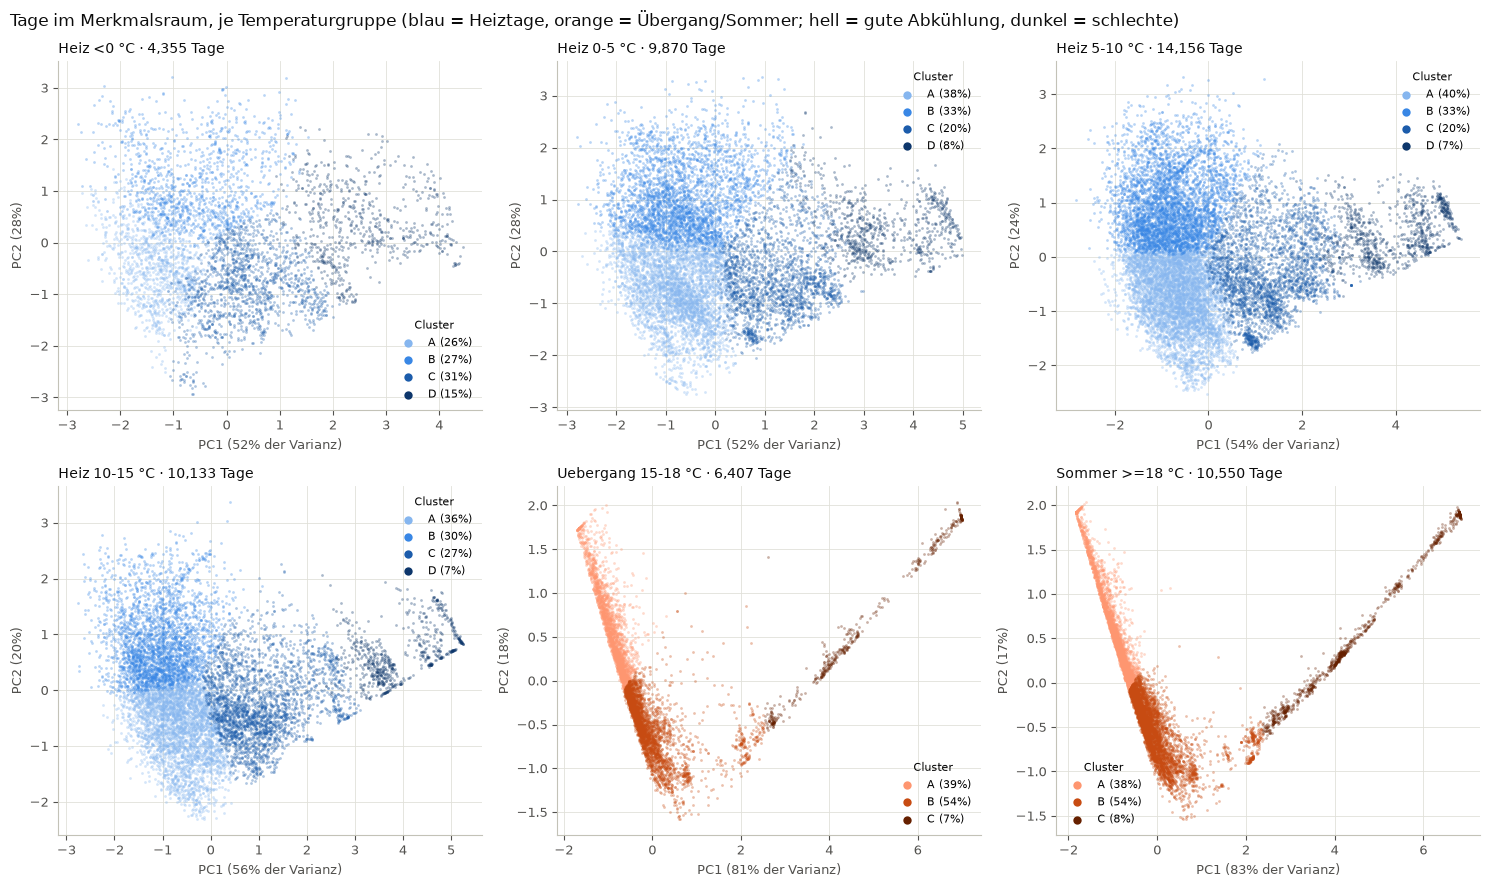

In [47]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (gruppe, e) in zip(axes.flat, ergebnisse.items()):
    pca = PCA(n_components=2, random_state=SEED).fit(e["Z"])
    P = pca.transform(e["Z"])
    farben = farben_fuer(gruppe, e["k"])
    for r in range(e["k"]):
        m = e["rang"] == r
        ax.scatter(P[m, 0], P[m, 1], s=4, alpha=0.35, color=farben[r], linewidths=0,
                   rasterized=True, label=f"{BUCHSTABEN[r]} ({m.mean():.0%})")
    ax.set_title(f"{gruppe} °C · {len(P):,} Tage", loc="left", fontsize=10, color=TINTE)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} der Varianz)", fontsize=9, color=TINTE_LEISE)
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%})", fontsize=9, color=TINTE_LEISE)
    legende = ax.legend(title="Cluster", fontsize=8, title_fontsize=8, markerscale=3, frameon=False)
    for h in legende.legend_handles:
        h.set_alpha(1)
    stil(ax)
for ax in list(axes.flat)[len(ergebnisse):]:
    ax.axis("off")
fig.suptitle("Tage im Merkmalsraum, je Temperaturgruppe (blau = Heiztage, orange = Übergang/Sommer; hell = gute Abkühlung, dunkel = schlechte)",
             x=0.01, ha="left", color=TINTE)
fig.tight_layout()
plt.show()

- Jeder Punkt ist ein Tag einer HAST. Die beiden Achsen fassen die Merkmale so zusammen,
  dass möglichst viel Unterschied sichtbar bleibt. Die Achsen haben keine Einheit.
- Klar getrennte Wolken = echte Tagestypen. Eine durchgehende Wolke, die nur zerschnitten
  wird = Kontinuum.

In [48]:
# Ladungen: wie stark jedes Merkmal in PC1 und PC2 steckt
ladungen = []
for gruppe, e in ergebnisse.items():
    pca = PCA(n_components=2, random_state=SEED).fit(e["Z"])
    for i, achse in enumerate(["PC1", "PC2"]):
        ladungen.append({"gruppe": gruppe, "achse": achse,
                         "Anteil Varianz %": round(100 * pca.explained_variance_ratio_[i]),
                         **dict(zip(MERKMALE_JE_GRUPPE[gruppe], pca.components_[i].round(2)))})
display(pd.DataFrame(ladungen).set_index(["gruppe", "achse"]))

Anteil Varianz %  kwh_pro_m3  volumen_m3_pro_kw  \
gruppe          achse                                                    
Heiz <0         PC1                  52       -0.56               0.62   
                PC2                  28       -0.43               0.20   
Heiz 0-5        PC1                  52       -0.56               0.61   
                PC2                  28       -0.42               0.21   
Heiz 5-10       PC1                  54       -0.54               0.59   
                PC2                  24       -0.43               0.21   
Heiz 10-15      PC1                  56       -0.53               0.56   
                PC2                  20       -0.43               0.30   
Uebergang 15-18 PC1                  81       -0.49               0.62   
                PC2                  18        0.87               0.31   
Sommer >=18     PC1                  83       -0.50               0.62   
                PC2                  17        0.86               0.31   

                       spreizung_p90_p10_k  fluss_cv  nachtfluss_lh_pro_kw  
gruppe          achse                                                       
Heiz <0         PC1                  -0.22     -0.50                   NaN  
                PC2                   0.81      0.36                   NaN  
Heiz 0-5        PC1                  -0.24     -0.51                   NaN  
                PC2                   0.82      0.32                   NaN  
Heiz 5-10       PC1                  -0.30     -0.52                   NaN  
                PC2                   0.86      0.19                   NaN  
Heiz 10-15      PC1                  -0.40     -0.51                   NaN  
                PC2                   0.85      0.11                   NaN  
Uebergang 15-18 PC1                    NaN       NaN                  0.61  
                PC2                    NaN       NaN                  0.39  
Sommer >=18     PC1                    NaN       NaN                  0.61  
                PC2                    NaN       NaN                  0.40

**Was steckt in PC1 und PC2?**
- Jede Achse ist eine Mischung aus **allen** Merkmalen der Gruppe; die Zahlen (**Ladungen**) sagen, wie stark.
- Werte zwischen −1 und 1: **großer Betrag** = Merkmal bestimmt die Achse stark, **nahe 0** = spielt kaum eine Rolle.
- **Gleiches Vorzeichen** = Merkmale wirken gemeinsam in dieselbe Richtung, **entgegengesetztes** = eines steigt, das andere fällt.
- Das Vorzeichen einer ganzen Achse ist beliebig (umgedreht wäre das Bild nur gespiegelt).
- Leere Felder: Merkmal kommt in dieser Gruppe nicht vor (Nachtfluss nur in Übergang/Sommer, Streuungen nur an Heiztagen).

**Zusammenfassung PCA und Ladungen**
- PCA sucht die Richtungen mit den größten Unterschieden in den Daten: PC1 (größte), PC2 (zweitgrößte); die Farben im Bild kommen aus dem Clustering, nicht aus der PCA
- Jede Achse ist eine Mischung aus allen Merkmalen; **Ladung²** = Anteil des Merkmals an der Achse (z. B. 0,59² ≈ 35 %), die Anteile einer Achse ergeben zusammen 100 %
- **Heiztage:**
    - **PC1 = Dauerdurchfluss-Achse** (52–56 % der Unterschiede): Volumen je kW (~35 %), Abkühlung (~29 %, umgekehrt) und Durchfluss-Schwankung (~27 %, umgekehrt) wirken gemeinsam → viel Wasser, konstanter Fluss, schlechte Abkühlung → Typ D liegt rechts
    - **PC2 = Schwankungs-Achse** (20–28 %): fast nur Streuung der Spreizung (~74 %) → Typ B liegt oben
    - Streuung ist eine eigene, fast unabhängige Dimension → deshalb entsteht B als eigener Typ
    - PC1 + PC2 zeigen zusammen 76–80 % der Unterschiede
- **Übergang/Sommer:**
    - **PC1** (81–83 %): Volumen je kW (~38 %) und Nachtfluss (~37 %) → trennt Dauerdurchfluss vom Rest
    - **PC2** (17–18 %): vor allem Abkühlung (~74 %) → trennt gut (A) von mäßig (B)
- Wichtigste Merkmalskombination überall: Wassermenge + Abkühlung + konstanter Fluss bzw. Nachtfluss; kein Merkmal ist überflüssig
- Grenze: Die PCA zeigt die Hauptunterschiede der Daten, nicht direkt, wie stark ein Merkmal über die Clusterzugehörigkeit entscheidet (→ Wichtigkeitstabelle in Abschnitt 8)


## 10 · Liegen die Tage einer HAST zusammen?

- **Konzentration** einer HAST = Anteil ihrer Tage im häufigsten Cluster. 100 % heißt: alle
  Tage im selben Cluster.
- **Vergleich mit Zufall:** Die Clusterzuordnung wird innerhalb der Gruppe 200-mal gemischt
  (gleiche Clustergrößen). Liegt die echte Konzentration deutlich darüber, prägt die
  Station ihre Tage.
- Berücksichtigt werden HAST mit mindestens 10 geclusterten Tagen in der Gruppe.

,HAST,Median tatsaechlich,Median Zufall,Anteil HAST >= 80 % in einem Cluster,bei Zufall
gruppe,,,,,
Heiz <0,88,0.80,0.35,0.50,0.0
Heiz 0-5,88,0.81,0.39,0.52,0.0
Heiz 5-10,88,0.74,0.40,0.44,0.0
Heiz 10-15,86,0.67,0.37,0.30,0.0
Uebergang 15-18,86,0.86,0.54,0.57,0.0
Sommer >=18,80,0.86,0.54,0.60,0.0


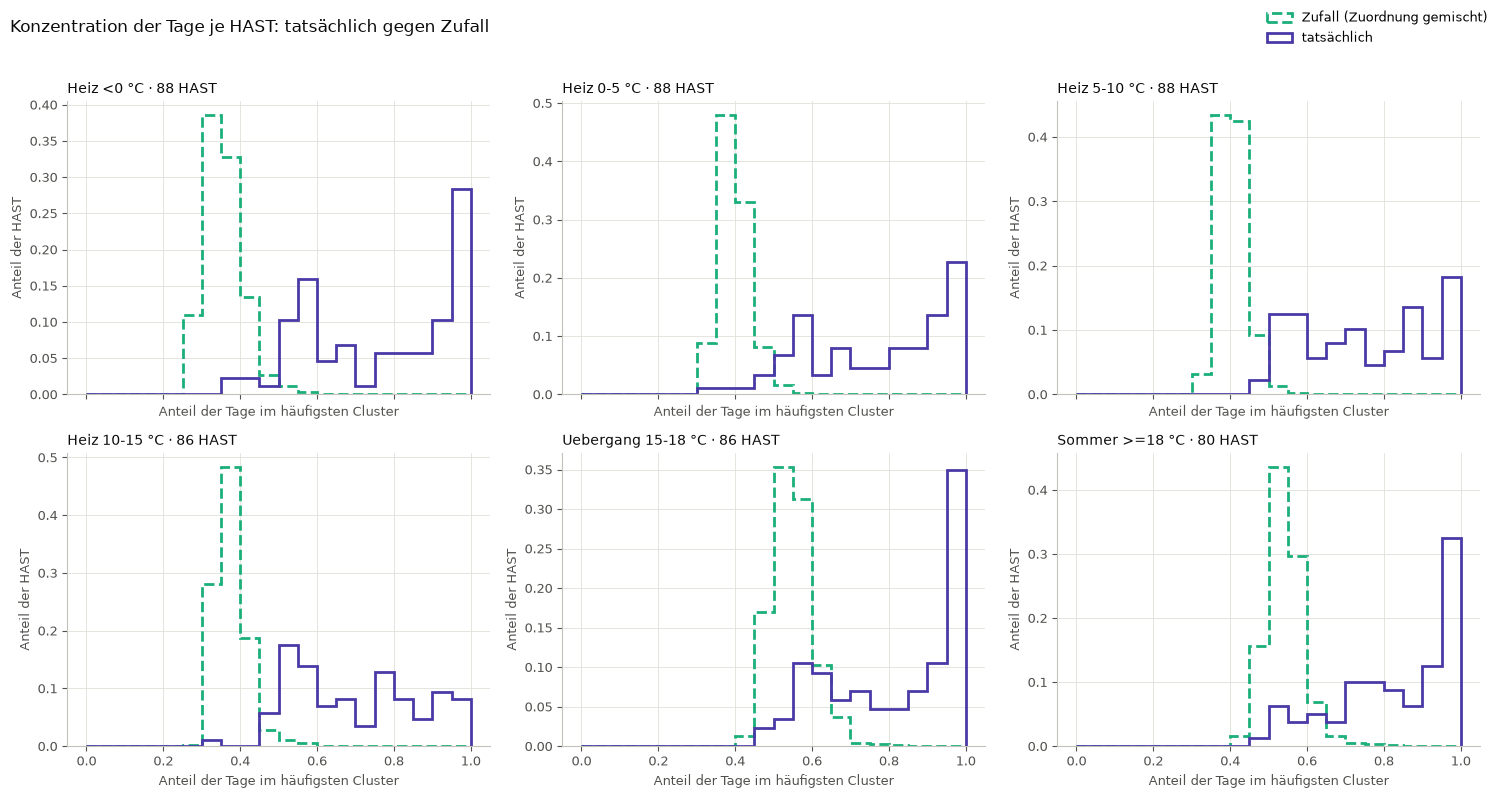

In [49]:
def konzentration(codes, rang, k):
    zaehl = np.bincount(codes * k + rang, minlength=(codes.max() + 1) * k).reshape(-1, k)
    return zaehl.max(axis=1) / zaehl.sum(axis=1)


rng = np.random.default_rng(SEED)
zeilen, verteilung = [], {}
for gruppe, e in ergebnisse.items():
    teil = e["teil"]
    genug = (teil["zaehler"].map(teil["zaehler"].value_counts()) >= MIN_TAGE_JE_HAST).to_numpy()
    if genug.sum() == 0:
        continue
    codes = pd.factorize(teil["zaehler"].to_numpy()[genug])[0]
    rang = e["rang"][genug].astype(int)
    echt = konzentration(codes, rang, e["k"])
    zufall = np.array([konzentration(codes, rng.permutation(rang), e["k"]) for _ in range(200)])
    verteilung[gruppe] = (echt, zufall.ravel())
    zeilen.append({"gruppe": gruppe, "HAST": len(echt),
                   "Median tatsaechlich": np.median(echt), "Median Zufall": np.median(zufall),
                   "Anteil HAST >= 80 % in einem Cluster": (echt >= 0.8).mean(),
                   "bei Zufall": (zufall >= 0.8).mean()})
display(pd.DataFrame(zeilen).set_index("gruppe").round(2))

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
kanten = np.linspace(0, 1, 21)
for ax, (gruppe, (echt, zufall)) in zip(axes.flat, verteilung.items()):
    ax.hist(zufall, bins=kanten, weights=np.full(len(zufall), 1 / len(zufall)), histtype="step",
            linewidth=2, linestyle="--", color=FARBE_ZUFALL, label="Zufall (Zuordnung gemischt)")
    ax.hist(echt, bins=kanten, weights=np.full(len(echt), 1 / len(echt)), histtype="step",
            linewidth=2, color=FARBE_TATSAECHLICH, label="tatsächlich")
    ax.set_title(f"{gruppe} °C · {len(echt)} HAST", loc="left", fontsize=10, color=TINTE)
    ax.set_xlabel("Anteil der Tage im häufigsten Cluster", fontsize=9, color=TINTE_LEISE)
    ax.set_ylabel("Anteil der HAST", fontsize=9, color=TINTE_LEISE)
    stil(ax)
for ax in list(axes.flat)[len(verteilung):]:
    ax.axis("off")
griffe, namen = axes.flat[0].get_legend_handles_labels()
fig.legend(griffe, namen, loc="upper right", frameon=False, fontsize=9)
fig.suptitle("Konzentration der Tage je HAST: tatsächlich gegen Zufall", x=0.01, ha="left", color=TINTE)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

- **Violette Kurve (tatsächlich) deutlich rechts von der türkisen (Zufall, gestrichelt):** Die Tage einer HAST landen überwiegend im
  selben Cluster. Die Cluster beschreiben dann eher Stationen als Tageszustände.
- **Beide Kurven ähnlich:** Die Cluster beschreiben Zustände, die bei vielen HAST vorkommen.
- Dazwischen ist der interessante Fall für später: HAST, die zwischen Clustern wechseln.
  Laut Folie 5 deutet das auf ein Regelproblem hin, gleichbleibend schlechte Tage eher auf
  einen Defekt.

## 11 · Cluster je HAST im Zeitverlauf

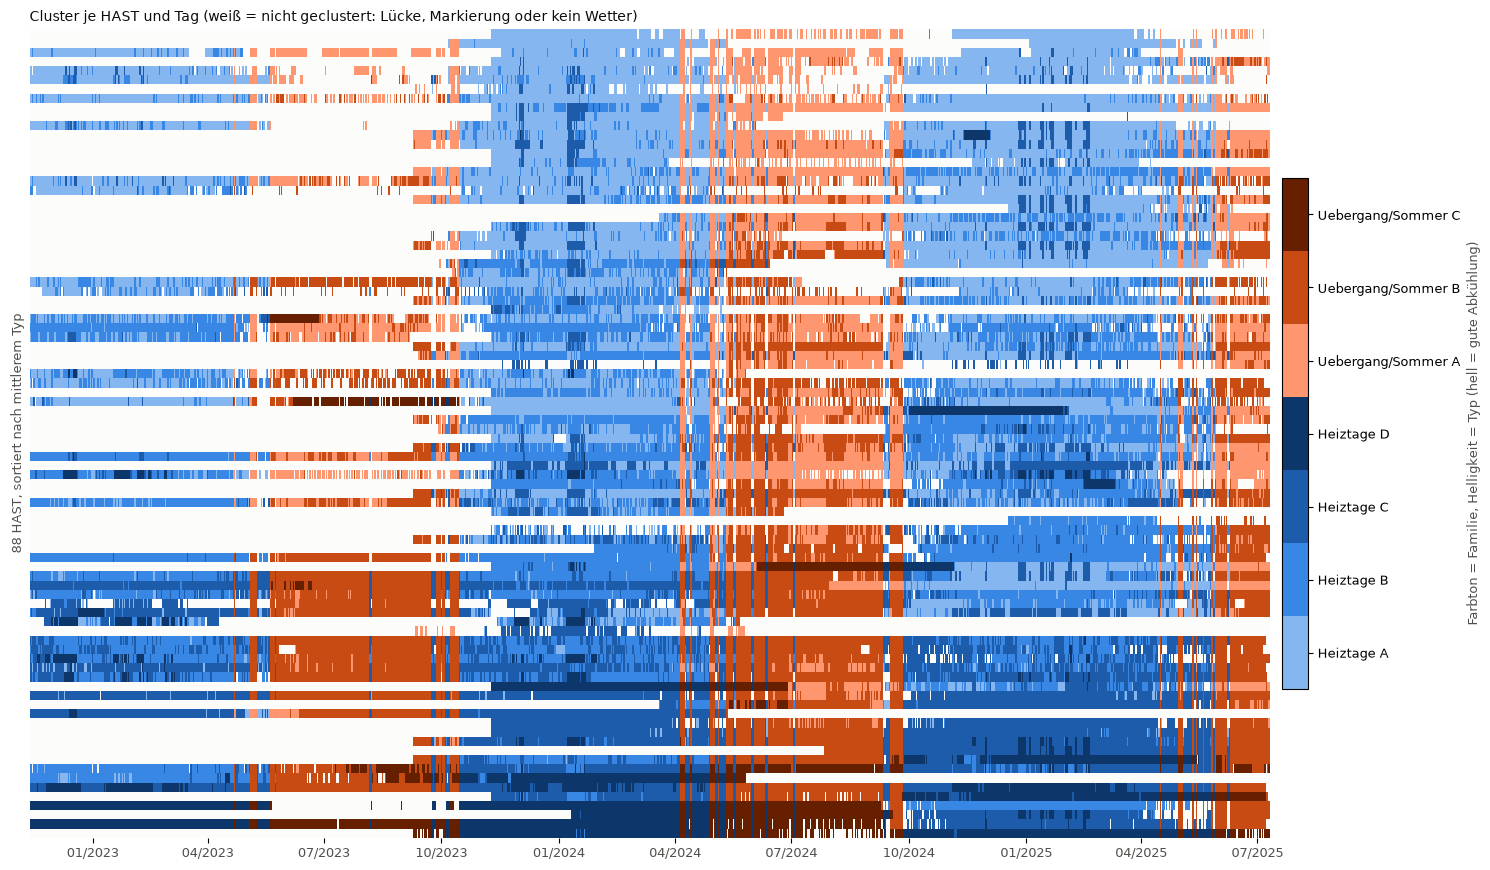

In [50]:
# Farbe je Tag: Heiztage in Blaustufen (A-D), Uebergang/Sommer in Orangestufen (A-C)
familie_von = {g: ("Uebergang/Sommer" if ist_sommerfamilie(g) else "Heiztage", e["k"])
               for g, e in ergebnisse.items()}
farben, namen, versatz = [], [], {}
for gruppe, (familie, k) in familie_von.items():
    if (familie, k) not in versatz:
        versatz[(familie, k)] = len(farben)
        farben += farben_fuer(gruppe, k)
        namen += [f"{familie} {BUCHSTABEN[r]}" for r in range(k)]

g = geclustert["gruppe"].astype(str)
farbindex = geclustert["cluster_rang"] + g.map(lambda x: versatz[familie_von[x]])
relativ = geclustert["cluster_rang"] / (g.map(lambda x: familie_von[x][1]) - 1)  # 0 = A ... 1 = schlechtester Typ
zeit = (geclustert.assign(farbindex=farbindex)
        .pivot_table(index="zaehler", columns="datum", values="farbindex", aggfunc="first"))
zeit = zeit.reindex(columns=pd.date_range(zeit.columns.min(), zeit.columns.max(), freq="D"))
zeit = zeit.loc[relativ.groupby(geclustert["zaehler"]).mean().sort_values().index]

farbskala = ListedColormap(farben)
farbskala.set_bad(FLAECHE)
fig, ax = plt.subplots(figsize=(15, max(4, 0.1 * len(zeit))))
bild = ax.imshow(np.ma.masked_invalid(zeit.to_numpy(dtype=float)), aspect="auto", interpolation="none",
                 cmap=farbskala, vmin=-0.5, vmax=len(farben) - 0.5)
quartale = list(pd.date_range(zeit.columns.min(), zeit.columns.max(), freq="QS"))
ax.set_xticks([zeit.columns.get_loc(d) for d in quartale])
ax.set_xticklabels([d.strftime("%m/%Y") for d in quartale], fontsize=9, color=TINTE_LEISE)
ax.set_yticks([])
ax.set_ylabel(f"{len(zeit)} HAST, sortiert nach mittlerem Typ", fontsize=9, color=TINTE_LEISE)
for seite in ax.spines.values():
    seite.set_visible(False)
leiste = fig.colorbar(bild, ax=ax, ticks=range(len(farben)), fraction=0.02, pad=0.01)
leiste.ax.set_yticklabels(namen, fontsize=9)
leiste.set_label("Farbton = Familie, Helligkeit = Typ (hell = gute Abkühlung)", fontsize=9, color=TINTE_LEISE)
ax.set_title("Cluster je HAST und Tag (weiß = nicht geclustert: Lücke, Markierung oder kein Wetter)",
             loc="left", fontsize=10, color=TINTE)
fig.tight_layout()
plt.show()

- Jede Zeile ist eine HAST, jede Spalte ein Tag. Zählernummern sind bewusst nicht beschriftet.
- **Farbton = Familie:** Blautöne sind Heiztage (Typen A–D), Orangetöne Übergangs- und
  Sommertage (Typen A–C). **Helligkeit = Typ:** hell = gute Abkühlung, dunkel = schlechte.
  Ein „A“ in Orange ist also nicht derselbe Typ wie ein „A“ in Blau.
- **Durchgehend gleiche Farbe:** Die HAST bleibt in ihrem Cluster.
- **Farbwechsel ab einem Datum:** Der Zustand der HAST ändert sich, etwa nach einer Reparatur.
  Solche Wechsel sind die Brücke zum nächsten Schritt mit den Begehungen.

## 12 · Ergebnis speichern

In [51]:
AUSGABE.parent.mkdir(parents=True, exist_ok=True)
SPALTEN_AUS = ["zaehler", "datum", "gruppe", "t_mittel_c", "nutzbar", "grund", "cluster",
               "kwh_pro_m3", "spreizung_k", "energie_kwh", "volumen_m3", "anschlusswert_kw",
               "volumen_m3_pro_kw", "spreizung_p90_p10_k", "fluss_cv", "nachtfluss_lh",
               "nachtfluss_lh_pro_kw", "n_stunden", "n_aktiv", "zaehler_spanne_h",
               "fluss_mittel_lh", "leistung_mittel_kw", "vorlauf_c", "ruecklauf_c"]
tage[SPALTEN_AUS].to_csv(AUSGABE, index=False)

anteile = (geclustert.groupby(["zaehler", "gruppe", "cluster"], observed=True).size()
           .groupby(level=[0, 1], observed=True).transform(lambda s: s / s.sum())
           .rename("anteil").reset_index())
anteile.to_csv(AUSGABE.with_name("hast_tage_clusteranteile.csv"), index=False)

meta = {
    "erzeugt": pd.Timestamp.now().isoformat(timespec="seconds"),
    "wetterstation": "DWD 2600 Kitzingen",
    "gruppen": GRUPPEN,
    "merkmale_je_gruppe": MERKMALE_JE_GRUPPE,
    "k_je_gruppe": {g: e["k"] for g, e in ergebnisse.items()},
    "referenz_je_gruppe": {g: e["referenz"] for g, e in ergebnisse.items()},
    "silhouette": json.loads(silhouette.round(3).to_json(orient="index")),
    "schwellen": {"max_abstand_h": MAX_ABSTAND_H, "aktiv_fluss_lh": AKTIV_FLUSS_LH,
                  "min_aktiv_stunden": MIN_AKTIV_STUNDEN, "min_stunden": MIN_STUNDEN,
                  "min_energie_kwh": MIN_ENERGIE_KWH, "max_kwh_pro_m3": MAX_KWH_PRO_M3,
                  "steht_leistung_kw": STEHT_LEISTUNG_KW, "min_tage_je_hast": MIN_TAGE_JE_HAST},
    "tageszeilen": int(len(tage)),
    "nutzbar": int(tage["nutzbar"].sum()),
    "geclustert": int(len(geclustert)),
}
AUSGABE.with_suffix(".json").write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"Tageszeilen   -> {AUSGABE.name}  ({len(tage):,} Zeilen)")
print(f"Clusteranteile -> hast_tage_clusteranteile.csv  ({len(anteile):,} Zeilen)")
print(f"Lauf-Kontext  -> {AUSGABE.with_suffix('.json').name}")

Tageszeilen   -> hast_tage.csv  (89,142 Zeilen)
Clusteranteile -> hast_tage_clusteranteile.csv  (1,221 Zeilen)
Lauf-Kontext  -> hast_tage.json


- `hast_tage.csv`: alle Tageszeilen mit Merkmalen, Markierungen und Cluster.
- `hast_tage_clusteranteile.csv`: je HAST und Gruppe der Anteil ihrer Tage pro Cluster.
  Das ist die Grundlage für Stationsprofile nach Folie 5.
- `hast_tage.json`: Parameter, K, Silhouette und Zeilenzahlen dieses Laufs.
- **Datenschutz:** Die CSVs enthalten Zählernummern. `data/processed/` ist gitignored und
  bleibt es.

## Erste Einordnung (nach dem ersten Lauf ausfüllen)

**Fragen an das Ergebnis**

1. Wie viele Tage sind je Gruppe nutzbar, und welche Markierung kostet am meisten?
   Kostet `wenig_energie` im Sommer zu viele Tage, wären Wochenwerte statt Tageswerte eine
   Option.
2. Gibt es überhaupt Struktur (Silhouette über 0,25)? Bei welchem K?
3. Unterscheiden sich die Cluster fachlich, oder nur in einem Merkmal?
4. Liegen die Tage einer HAST zusammen (Konzentration deutlich über Zufall)?
5. Zeigt der Zeitverlauf Wechsel, die zu bekannten Ereignissen passen, etwa dem
   Ventilfall im September 2024? Das wäre der Einstieg in den Schritt mit den Begehungen.

**Bekannte Grenzen dieses Entwurfs**

- Zählertausch ist nicht zusammengeführt: Eine HAST mit Tausch erscheint als zwei Zähler.
- Wetterdaten bis 31.12.2025. 2026 hat ohnehin keine Zählerstände.
- K (4 an Heiztagen, 3 in Übergang und Sommer) und alle Schwellen sind Startwerte.
- Die Streuung stammt aus Momentaufnahmen und enthält auch zufällige Warmwasserzapfungen.